In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]  # adjust based on output
SRC_PATH = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_PATH))

from build_product_graph import load_graph, visualize_graph, query_brand, get_cross_platform_pairs, get_ulta_only_products

In [2]:
G = load_graph()

In [3]:
from collections import Counter

node_types = Counter(d["node_type"] for _, d in G.nodes(data=True))
print("Node type counts:")
for ntype, count in sorted(node_types.items(), key=lambda x: -x[1]):
    print(f"  {ntype:<25} {count:,}")

print(f"\nTotal nodes : {G.number_of_nodes():,}")
print(f"Total edges : {G.number_of_edges():,}")

Node type counts:
  ulta_only                 3,433
  matched_product           379
  sephora_sku               379
  ulta_sku                  379
  brand                     142

Total nodes : 4,712
Total edges : 5,328


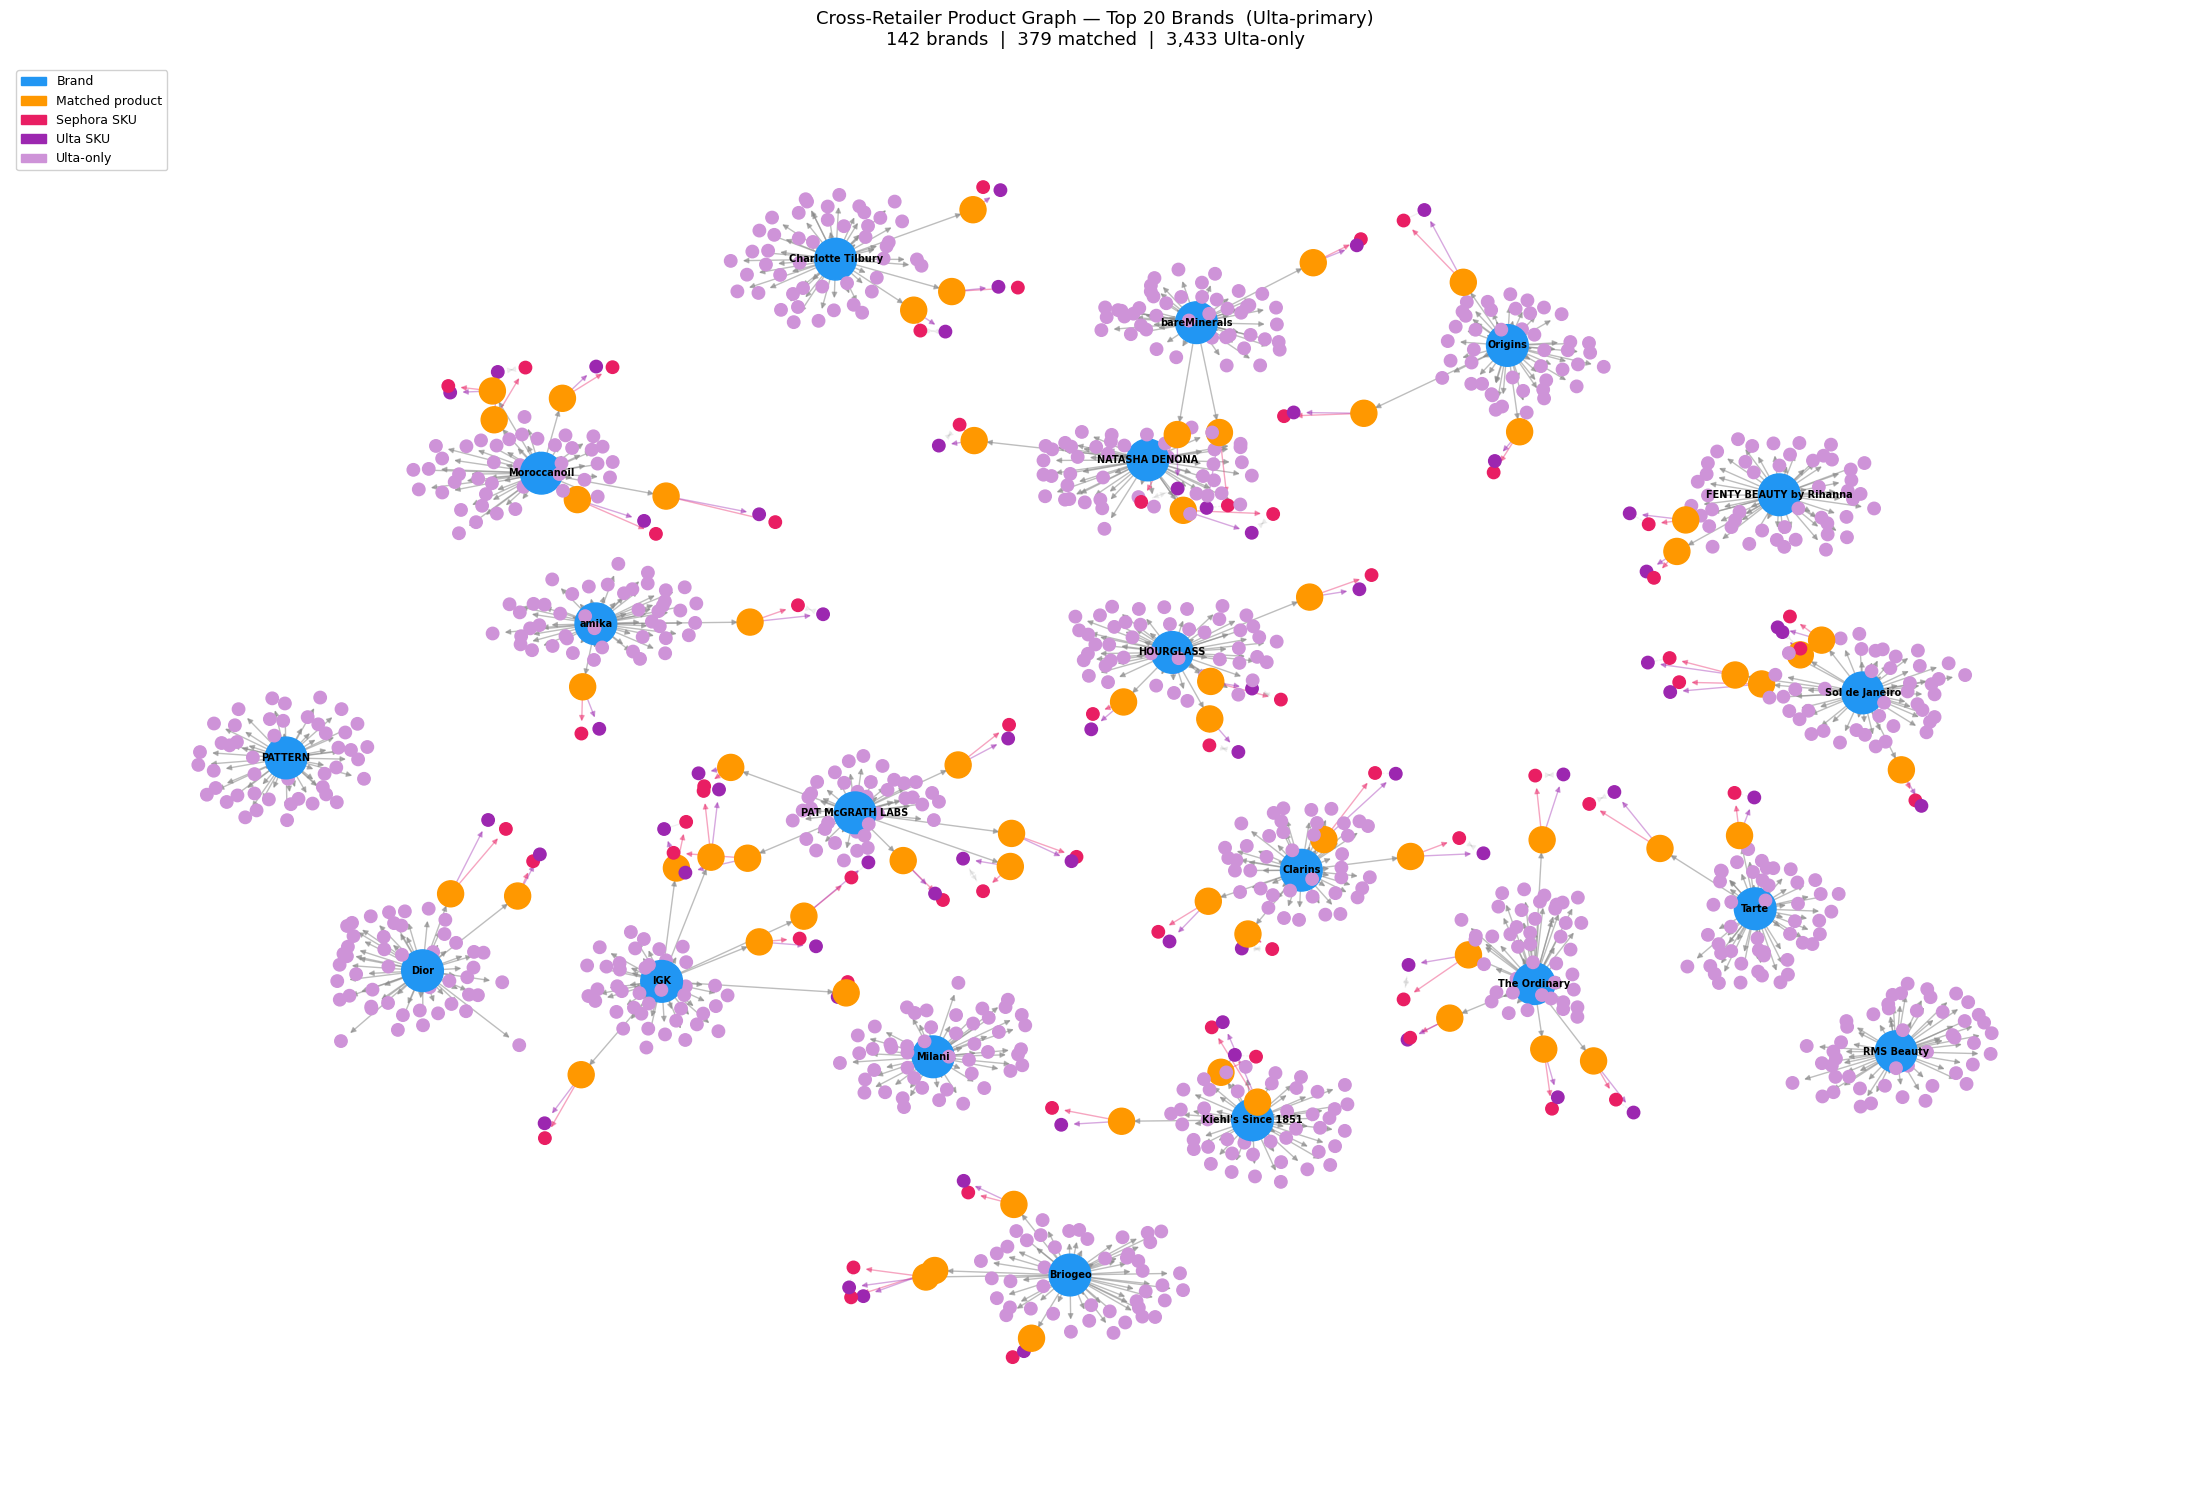

In [4]:
fig = visualize_graph(G, mode="brand_network", top_n=20)

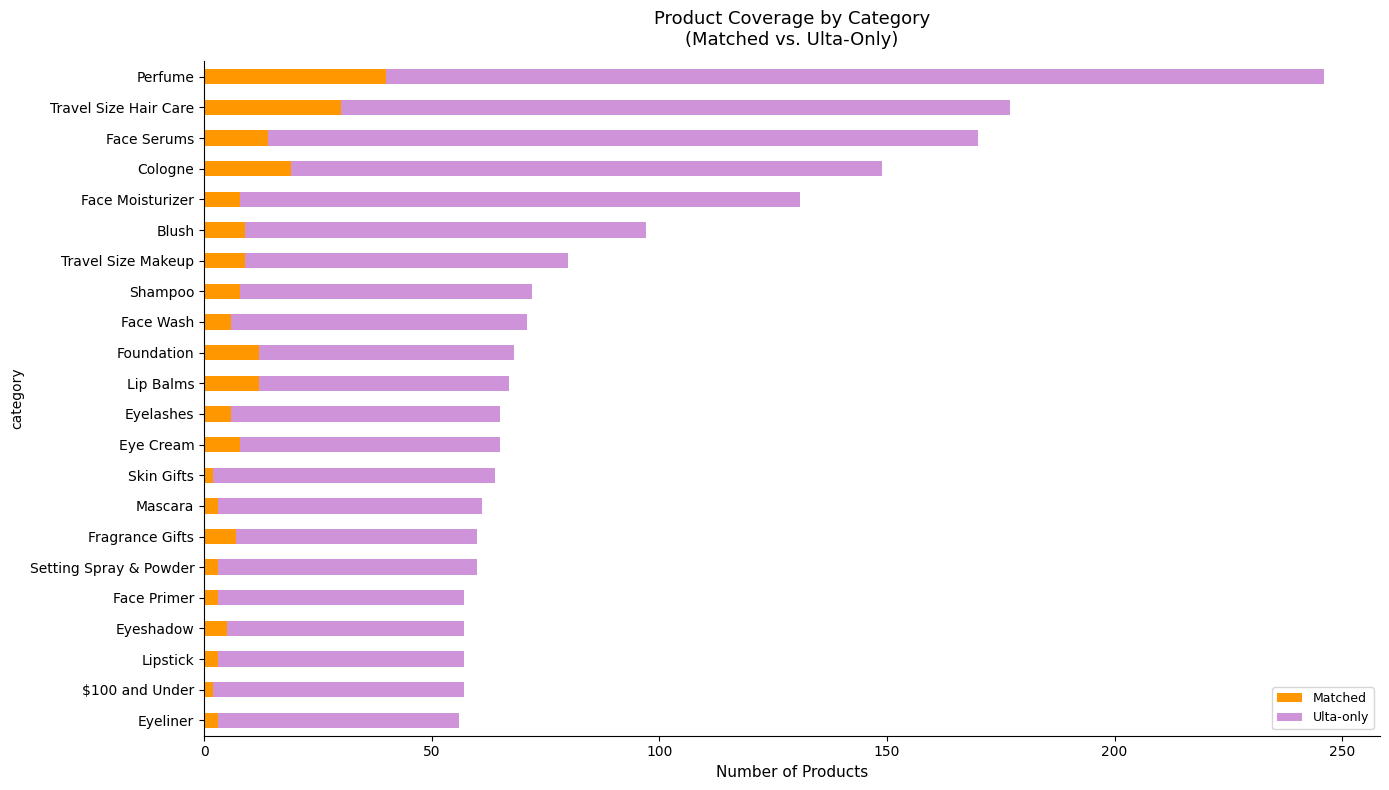

In [5]:
fig = visualize_graph(G, mode="category_heatmap")

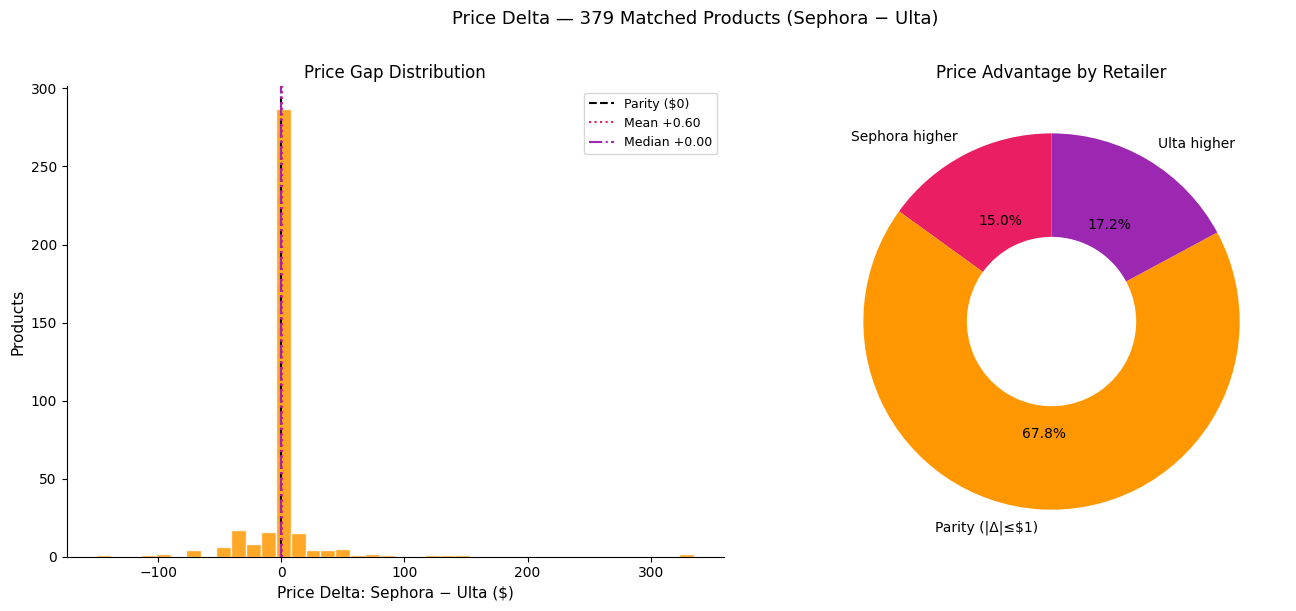

In [6]:
fig = visualize_graph(G, mode="price_delta")

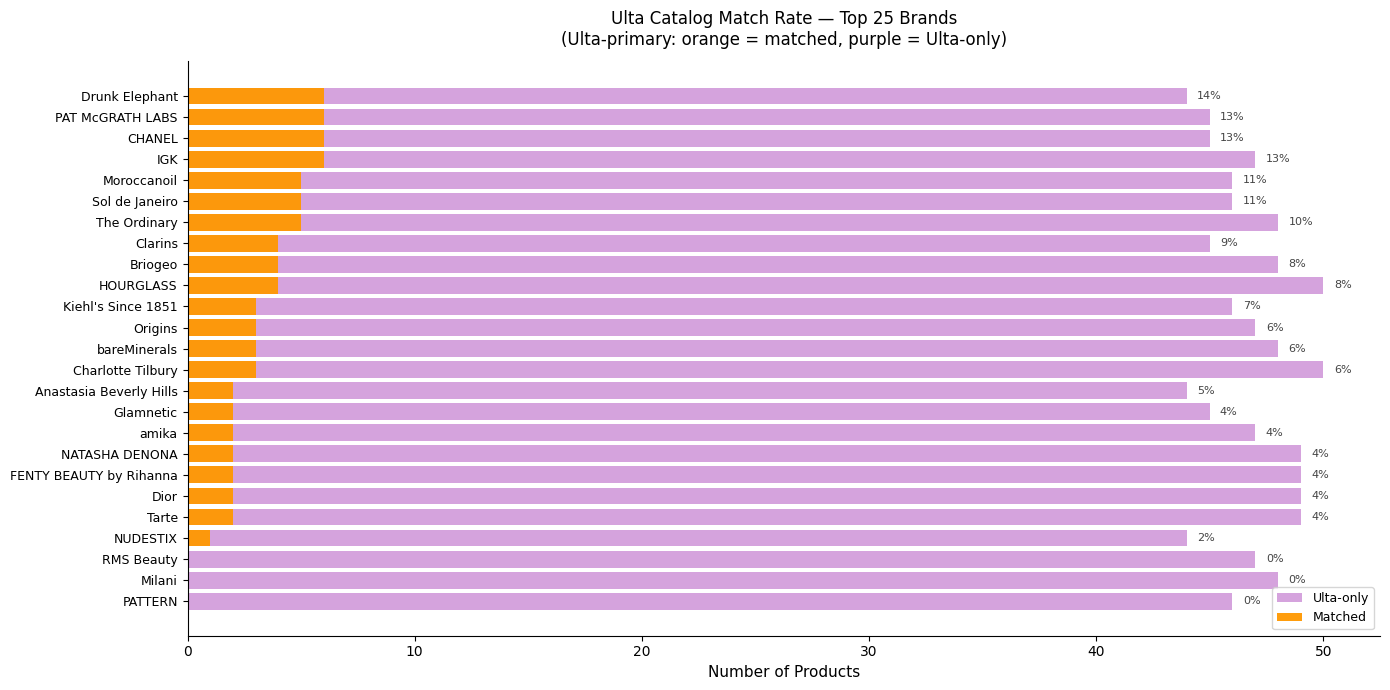

In [7]:
fig = visualize_graph(G, mode="coverage", top_n=25)

In [9]:
fig.savefig("outputs/product_graph_fig.png", dpi=150, bbox_inches="tight")

In [10]:
pairs = get_cross_platform_pairs(G)
print(f"{len(pairs):,} matched pairs\n")
print(pairs[["sephora_product_name", "ulta_product_name",
             "sephora_price", "ulta_price", "price_delta",
             "sephora_rating", "ulta_rating", "rating_delta",
             "similarity"]].head(10).to_string(index=False))

379 matched pairs

                                             sephora_product_name                                ulta_product_name  sephora_price  ulta_price  price_delta  sephora_rating  ulta_rating  rating_delta  similarity
                    Perfect Defense Heat Protectant - Moroccanoil         Perfect Defense Heat Protectant - 6.0 oz           32.0        32.0          0.0        4.549985          4.7     -0.150015         1.0
                    All in One Leave-In Conditioner - Moroccanoil                  All in One Leave-In Conditioner           32.0        32.0          0.0        4.533208          4.6     -0.066792         1.0
                                  Hydrating Shampoo - Moroccanoil                       Hydrating Shampoo - 8.5 oz           30.0        30.0          0.0        4.209677          4.3     -0.090323         1.0
                              Hydrating Conditioner - Moroccanoil                   Hydrating Conditioner - 8.5 oz           30.0        30.0

In [11]:
ulta_only = get_ulta_only_products(G)
print(f"{len(ulta_only):,} Ulta-only products (no Sephora match)\n")
print(ulta_only[["brand", "product_name", "category", "price", "rating"]].head(10))

3,433 Ulta-only products (no Sephora match)

           brand                                   product_name  \
0  Ariana Grande   r.e.m. Cherry Eclipse Eau de Parfum - 3.4 oz   
1  Ariana Grande         MOD Blush Eau de Parfum Spray - 3.4 oz   
2  Ariana Grande   LOVENOTES Pink Woods Eau de Parfum - 4.25 oz   
3  Ariana Grande                Cloud 2.0 Intense Eau de Parfum   
4  Ariana Grande            Thank U Next Eau de Parfum - 3.4 oz   
5  Ariana Grande                  R.E.M. Eau de Parfum - 3.4 oz   
6  Ariana Grande         Wicked Elphaba Enchanted Eau de Parfum   
7  Ariana Grande  Sweet Like Candy By Ariana Grande 2-Piece Set   
8  Ariana Grande                   MOD Vanilla Mini 2-Piece Set   
9  Ariana Grande                  Ariana Grande 4-Piece Coffret   

          category  price  rating  
0          Perfume   72.0     4.5  
1          Perfume   72.0     4.3  
2          Perfume   80.0     4.2  
3          Perfume   72.0     4.2  
4          Perfume   72.0     4.0  
5

In [12]:
brand_df = query_brand(G, "charlotte tilbury")   # case-insensitive
print(f"{len(brand_df)} products for Charlotte Tilbury\n")
print(brand_df[["node_type", "product_name", "price", "rating"]].to_string(index=False))

50 products for Charlotte Tilbury

      node_type                                                          product_name  price  rating
matched_product                       Airbrush Flawless Finish Setting Powder - 3 Tan    NaN     NaN
matched_product                                Hollywood Flawless Filter - 4.5 Medium    NaN     NaN
matched_product                                     Lip Cheat Lip Liner - Pillow Talk    NaN     NaN
      ulta_only                              Airbrush Flawless Setting Spray - 3.3 oz   39.0     4.1
      ulta_only                       Airbrush Flawless Blur Concealer - 8 Medium-Tan   36.0     4.7
      ulta_only                                 Airbrush Flawless Foundation - 6 Cool   52.0     4.5
      ulta_only                                Matte Revolution Lipstick - Catwalking   37.0     4.6
      ulta_only                 Magic Cream Moisturizer with Hyaluronic Acid - 1.7 oz  105.0     4.6
      ulta_only                                       Ai

In [13]:
import numpy as np

price_pairs = pairs.dropna(subset=["price_delta"])
arr = price_pairs["price_delta"].values
print(f"Price delta (Sephora − Ulta) across {len(arr):,} matched products:")
print(f"  Mean          : ${arr.mean():+.2f}")
print(f"  Median        : ${np.median(arr):+.2f}")
print(f"  Sephora higher: {(arr > 1).sum():,}  ({(arr > 1).mean()*100:.1f}%)")
print(f"  Ulta higher   : {(arr < -1).sum():,}  ({(arr < -1).mean()*100:.1f}%)")
print(f"  Parity |Δ|≤$1 : {(np.abs(arr) <= 1).sum():,}  ({(np.abs(arr) <= 1).mean()*100:.1f}%)")

Price delta (Sephora − Ulta) across 379 matched products:
  Mean          : $+0.60
  Median        : $+0.00
  Sephora higher: 57  (15.0%)
  Ulta higher   : 65  (17.2%)
  Parity |Δ|≤$1 : 257  (67.8%)


In [14]:
rating_pairs = pairs.dropna(subset=["rating_delta"])
arr = rating_pairs["rating_delta"].values
print(f"Rating delta (Sephora − Ulta) across {len(arr):,} matched products:")
print(f"  Mean          : {arr.mean():+.3f} ★")
print(f"  Median        : {np.median(arr):+.3f} ★")
print(f"  Sephora higher: {(arr > 0).sum():,}  ({(arr > 0).mean()*100:.1f}%)")
print(f"  Ulta higher   : {(arr < 0).sum():,}  ({(arr < 0).mean()*100:.1f}%)")

Rating delta (Sephora − Ulta) across 379 matched products:
  Mean          : -0.114 ★
  Median        : -0.097 ★
  Sephora higher: 122  (32.2%)
  Ulta higher   : 255  (67.3%)
